# 🌳 Hierarchical Clustering — Dendrograms and Nested Structure

K-Means (previous topic) requires choosing $k$ upfront and only ever produces spherical clusters. Hierarchical clustering does neither: it builds a full nested tree of every possible clustering from $n$ individual points down to 1 giant cluster, letting $k$ be chosen *after* seeing the structure, and -- depending on the linkage method -- can represent non-spherical shapes K-Means structurally cannot. This notebook builds the algorithm from scratch, compares every standard linkage method, and directly re-tests the two findings from the K-Means topic: the interleaving-crescents failure case and the Iris recovery score.

📖 Full mathematical explanation (linkage criteria, the cophenetic correlation, computational cost): [README.md](README.md)


## 1. Setup & Datasets

The identical blobs, moons, and Iris datasets used in the K-Means topic, so every comparison in this notebook is direct -- plus one tiny 8-point toy dataset specifically for tracing the merge algorithm by hand.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=42)
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.08, random_state=42)
iris = load_iris()
X_iris, y_iris_true = iris.data, iris.target
print(f"Blobs: {X_blobs.shape}, Moons: {X_moons.shape}, Iris: {X_iris.shape}")
print("(Identical datasets to the K-Means topic -- every ARI comparison below is directly comparable to that notebook's numbers.)")


Blobs: (300, 2), Moons: (300, 2), Iris: (150, 4)
(Identical datasets to the K-Means topic -- every ARI comparison below is directly comparable to that notebook's numbers.)


Tiny toy dataset for tracing merges by hand: 8 points


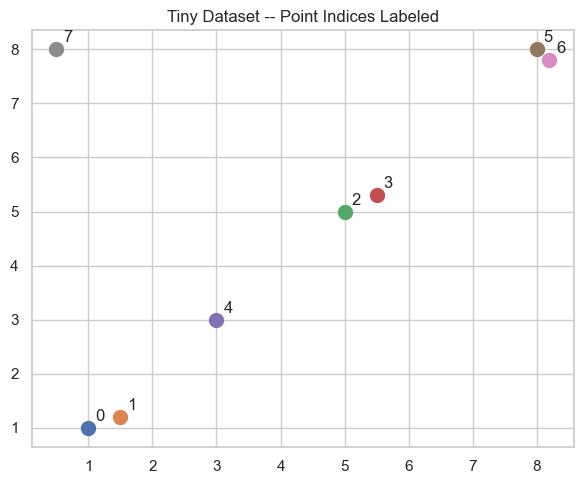

In [3]:
X_tiny = np.array([[1, 1], [1.5, 1.2], [5, 5], [5.5, 5.3], [3, 3], [8, 8], [8.2, 7.8], [0.5, 8]])
print(f"Tiny toy dataset for tracing merges by hand: {X_tiny.shape[0]} points")
fig, ax = plt.subplots(figsize=(6, 5))
for i, (x, y) in enumerate(X_tiny):
    ax.scatter(x, y, s=100)
    ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(5, 5))
ax.set_title("Tiny Dataset -- Point Indices Labeled")
plt.tight_layout()
plt.show()


## 2. Agglomerative Clustering From Scratch

Start with every point as its own cluster. Repeatedly merge the two *closest* clusters (by whichever linkage rule is chosen) into one, recording each merge, until only one cluster remains. This bottom-up approach is what "hierarchical clustering" means in practice -- the top-down (divisive) alternative exists but is rarely used, since it requires solving a harder sub-problem (how to split) at every step instead of an easier one (which pair to merge).


In [4]:
def agglomerative_from_scratch(X, linkage_fn):
    n = len(X)
    clusters = {i: [i] for i in range(n)}
    active = list(range(n))
    next_id = n
    merge_history = []

    while len(active) > 1:
        best_pair, best_dist = None, np.inf
        for i in range(len(active)):
            for j in range(i + 1, len(active)):
                d = linkage_fn(X, clusters[active[i]], clusters[active[j]])
                if d < best_dist:
                    best_dist, best_pair = d, (active[i], active[j])

        a, b = best_pair
        merged_members = clusters[a] + clusters[b]
        clusters[next_id] = merged_members
        merge_history.append((a, b, best_dist, len(merged_members)))
        active.remove(a)
        active.remove(b)
        active.append(next_id)
        next_id += 1

    return merge_history

def single_linkage(X, cluster_a, cluster_b):
    return min(np.linalg.norm(X[i] - X[j]) for i in cluster_a for j in cluster_b)

print("From-scratch agglomerative clustering (generic linkage) and single-linkage distance function defined.")


From-scratch agglomerative clustering (generic linkage) and single-linkage distance function defined.


In [5]:
manual_merges = agglomerative_from_scratch(X_tiny, single_linkage)
print("Manual single-linkage merge history (cluster_a, cluster_b, distance, new_size):")
for m in manual_merges:
    print(f"  {m}")


Manual single-linkage merge history (cluster_a, cluster_b, distance, new_size):
  (5, 6, np.float64(0.2828427124746186), 2)
  (0, 1, np.float64(0.5385164807134504), 2)
  (2, 3, np.float64(0.58309518948453), 2)
  (4, 9, np.float64(2.3430749027719964), 3)
  (10, 11, np.float64(2.8284271247461903), 5)
  (8, 12, np.float64(3.679673898594819), 7)
  (7, 13, np.float64(5.408326913195984), 8)


In [6]:
scipy_linkage_matrix = linkage(X_tiny, method="single", metric="euclidean")
print("scipy's linkage matrix (same format: idx1, idx2, distance, new_cluster_size):")
print(np.round(scipy_linkage_matrix, 3))

manual_distances = [round(m[2], 3) for m in manual_merges]
scipy_distances = [round(d, 3) for d in scipy_linkage_matrix[:, 2]]
print(f"\nManual merge distances: {manual_distances}")
print(f"scipy merge distances:  {scipy_distances}")
print(f"Match? {manual_distances == scipy_distances}")


scipy's linkage matrix (same format: idx1, idx2, distance, new_cluster_size):
[[ 5.     6.     0.283  2.   ]
 [ 0.     1.     0.539  2.   ]
 [ 2.     3.     0.583  2.   ]
 [ 4.     9.     2.343  3.   ]
 [10.    11.     2.828  5.   ]
 [ 8.    12.     3.68   7.   ]
 [ 7.    13.     5.408  8.   ]]

Manual merge distances: [np.float64(0.283), np.float64(0.539), np.float64(0.583), np.float64(2.343), np.float64(2.828), np.float64(3.68), np.float64(5.408)]
scipy merge distances:  [np.float64(0.283), np.float64(0.539), np.float64(0.583), np.float64(2.343), np.float64(2.828), np.float64(3.68), np.float64(5.408)]
Match? True


In [7]:
def complete_linkage(X, cluster_a, cluster_b):
    return max(np.linalg.norm(X[i] - X[j]) for i in cluster_a for j in cluster_b)

manual_merges_complete = agglomerative_from_scratch(X_tiny, complete_linkage)
scipy_complete = linkage(X_tiny, method="complete", metric="euclidean")

manual_complete_dists = [round(m[2], 3) for m in manual_merges_complete]
scipy_complete_dists = [round(d, 3) for d in scipy_complete[:, 2]]
print(f"Manual complete-linkage merge distances: {manual_complete_dists}")
print(f"scipy complete-linkage merge distances:  {scipy_complete_dists}")
print(f"Match? {manual_complete_dists == scipy_complete_dists}")
print("-> The from-scratch implementation generalizes correctly to a second linkage rule just by swapping the distance function, confirming the merge LOOP (not just single-linkage specifically) is correct.")


Manual complete-linkage merge distances: [np.float64(0.283), np.float64(0.539), np.float64(0.583), np.float64(2.828), np.float64(4.252), np.float64(7.018), np.float64(9.904)]
scipy complete-linkage merge distances:  [np.float64(0.283), np.float64(0.539), np.float64(0.583), np.float64(2.828), np.float64(4.252), np.float64(7.018), np.float64(9.904)]
Match? True
-> The from-scratch implementation generalizes correctly to a second linkage rule just by swapping the distance function, confirming the merge LOOP (not just single-linkage specifically) is correct.


## 3. The Dendrogram

A dendrogram plots every merge as a horizontal line at the height of its merge distance -- reading it top-to-bottom shows the full hierarchy from 1 cluster down to $n$ individual points.


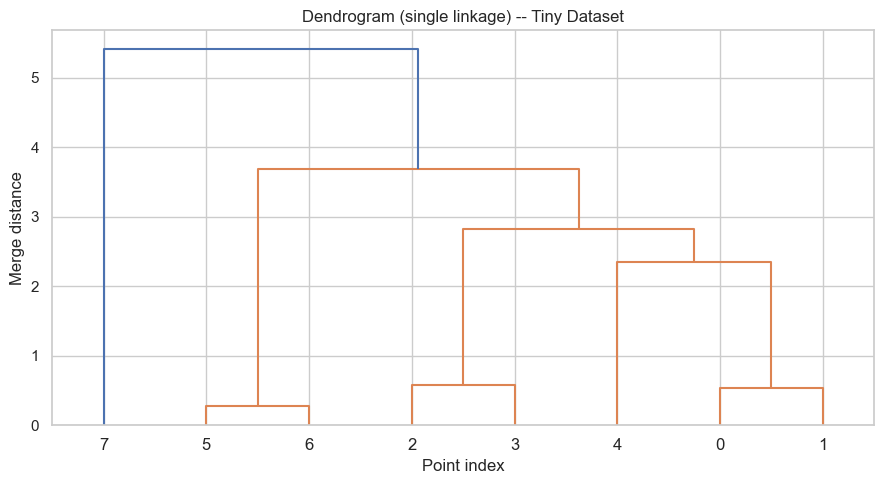

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(scipy_linkage_matrix, labels=[str(i) for i in range(len(X_tiny))], ax=ax)
ax.set_xlabel("Point index"); ax.set_ylabel("Merge distance")
ax.set_title("Dendrogram (single linkage) -- Tiny Dataset")
plt.tight_layout()
plt.show()


In [9]:
print("Reading the dendrogram: points 0 and 1 merge first (closest pair), then 2 and 3, then 5 and 6.")
print("Point 7 (0.5, 8) stays isolated the longest -- visually confirm it's the most distant point from every cluster in Section 1's scatter plot.")


Reading the dendrogram: points 0 and 1 merge first (closest pair), then 2 and 3, then 5 and 6.
Point 7 (0.5, 8) stays isolated the longest -- visually confirm it's the most distant point from every cluster in Section 1's scatter plot.


## 4. Linkage Criteria — Four Different Definitions of "Closest"

$$\text{Single: } \min_{a \in A, b \in B} d(a,b) \qquad \text{Complete: } \max_{a \in A, b \in B} d(a,b) \qquad \text{Average: } \frac{1}{|A||B|}\sum_{a,b} d(a,b) \qquad \text{Ward: minimizes increase in total within-cluster variance}$$

Every linkage method builds the *same kind* of tree, but "distance between two clusters" means something different each time -- producing meaningfully different dendrograms and final clusterings from identical data.


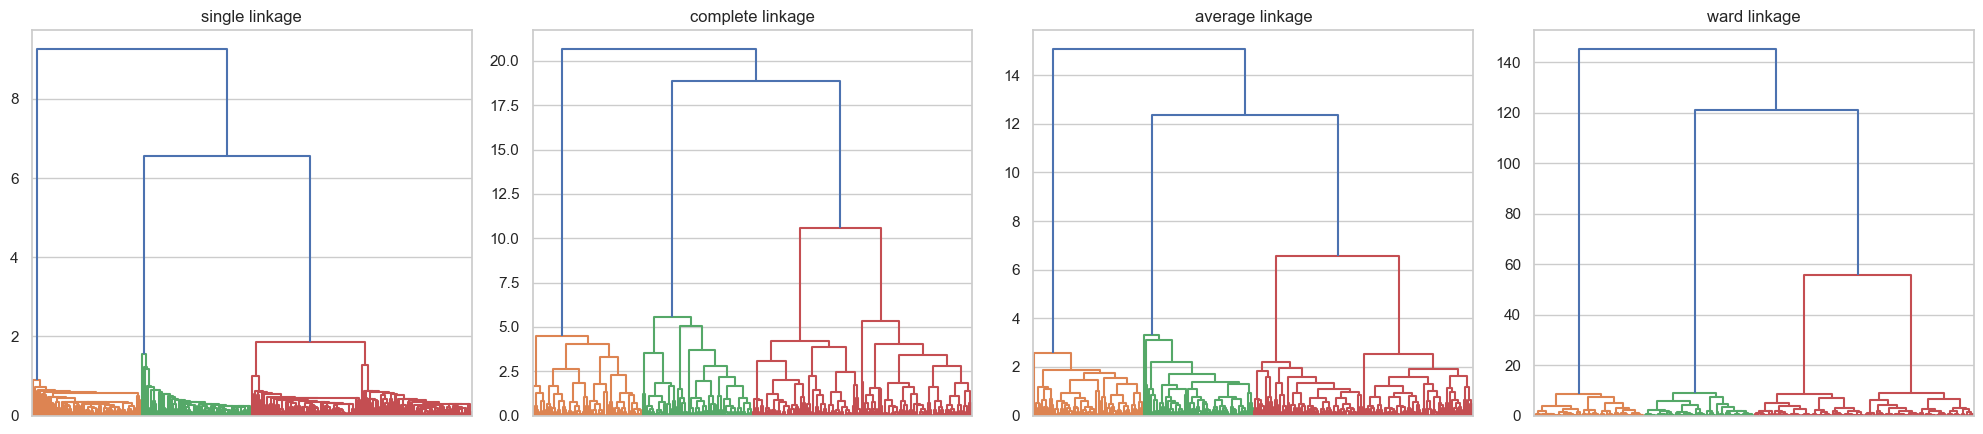

In [10]:
linkage_methods = ["single", "complete", "average", "ward"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_blobs, method=method)
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f"{method} linkage")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


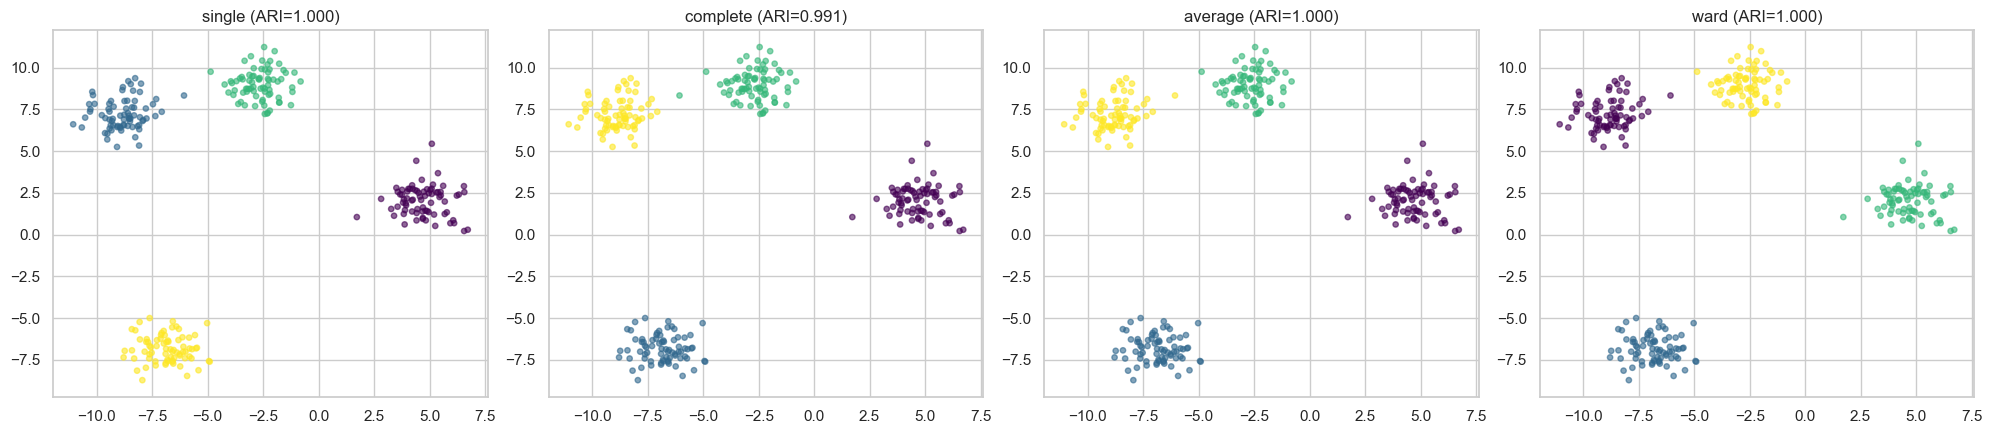

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, method in zip(axes, linkage_methods):
    model = AgglomerativeClustering(n_clusters=4, linkage=method).fit(X_blobs)
    ari = adjusted_rand_score(y_blobs_true, model.labels_)
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=model.labels_, cmap="viridis", alpha=0.6, s=15)
    ax.set_title(f"{method} (ARI={ari:.3f})")
plt.tight_layout()
plt.show()


## 5. Cutting the Dendrogram — Choosing k After the Fact

Unlike K-Means, `k` doesn't need to be decided before fitting -- the full tree is built once, then "cut" at whatever height (equivalently, whatever cluster count) is wanted afterward.


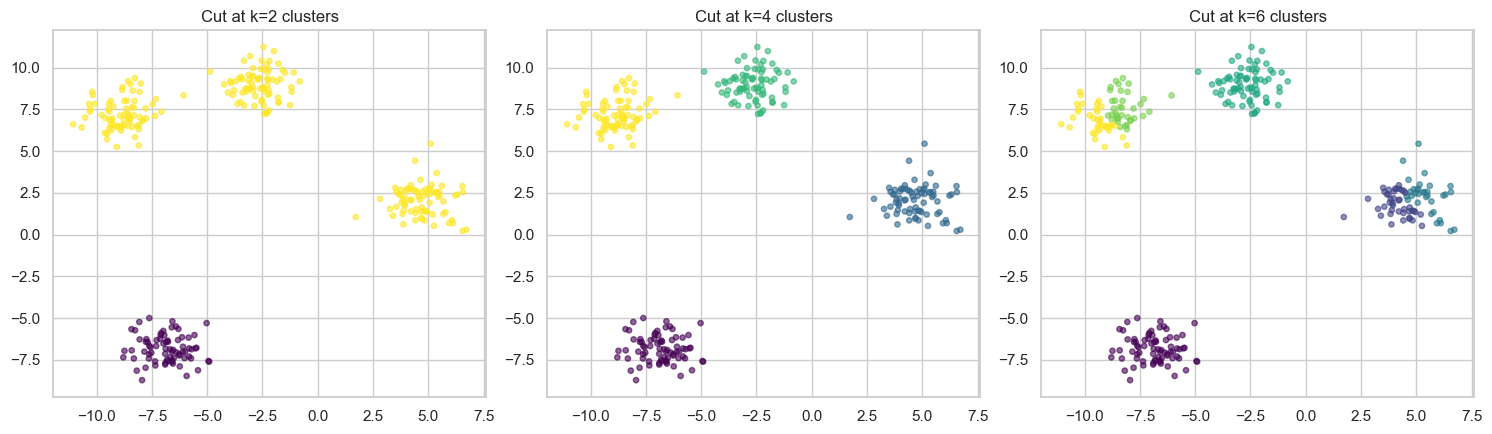

-> All three clusterings above came from the SAME fitted tree (Z_blobs_ward) -- no refitting needed to explore different k, unlike K-Means where each k requires a completely new fit.


In [12]:
Z_blobs_ward = linkage(X_blobs, method="ward")
cut_heights_to_show = [2, 4, 6]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, k in zip(axes, cut_heights_to_show):
    labels_at_k = fcluster(Z_blobs_ward, t=k, criterion="maxclust")
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_at_k, cmap="viridis", alpha=0.6, s=15)
    ax.set_title(f"Cut at k={k} clusters")
plt.tight_layout()
plt.show()
print("-> All three clusterings above came from the SAME fitted tree (Z_blobs_ward) -- no refitting needed to explore different k, unlike K-Means where each k requires a completely new fit.")


## 6. The Cophenetic Correlation — Which Linkage Best Represents the Data?

The cophenetic distance between two points is the height at which they first end up in the same cluster in the dendrogram. Correlating cophenetic distances against the *actual* pairwise distances measures how faithfully a given linkage method's tree represents the original data's geometry.


In [13]:
cophenetic_results = []
for method in linkage_methods:
    Z = linkage(X_blobs, method=method)
    coph_corr, coph_dists = cophenet(Z, pdist(X_blobs))
    cophenetic_results.append({"linkage": method, "cophenetic_correlation": round(coph_corr, 4)})
print(f"Computed cophenetic correlation for {len(linkage_methods)} linkage methods.")


Computed cophenetic correlation for 4 linkage methods.


In [14]:
pd.DataFrame(cophenetic_results)


,linkage,cophenetic_correlation
0,single,0.9422
1,complete,0.9514
2,average,0.9579
3,ward,0.9569


In [15]:
print("-> Higher cophenetic correlation means the dendrogram's merge heights better preserve the true pairwise distances -- useful for picking a linkage method BEFORE knowing how many true clusters exist, since it doesn't require choosing k first.")


-> Higher cophenetic correlation means the dendrogram's merge heights better preserve the true pairwise distances -- useful for picking a linkage method BEFORE knowing how many true clusters exist, since it doesn't require choosing k first.


## 7. Re-Testing K-Means' Failure Case — Interleaving Crescents

The K-Means topic found ARI collapsing to 0.261 on two interleaving crescents, since no single-centroid distance measure can represent a crescent. Testing whether any linkage method does better.


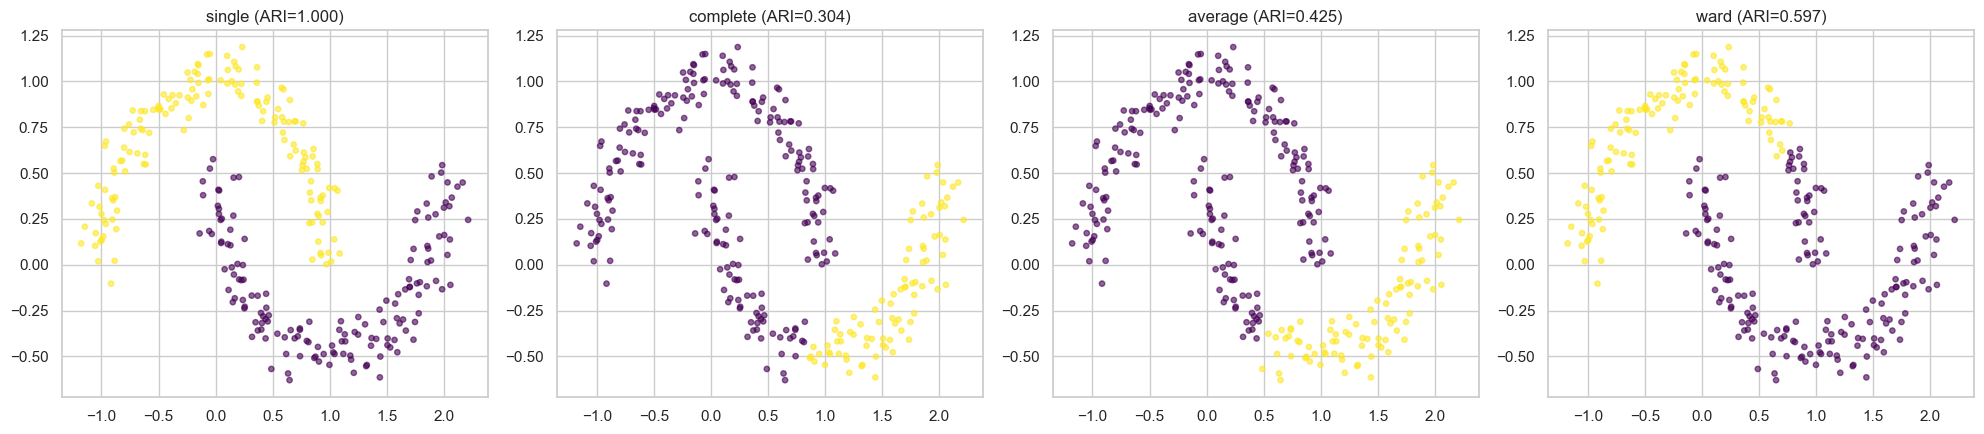

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
moons_results = {}
for ax, method in zip(axes, linkage_methods):
    model = AgglomerativeClustering(n_clusters=2, linkage=method).fit(X_moons)
    ari = adjusted_rand_score(y_moons_true, model.labels_)
    moons_results[method] = ari
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=model.labels_, cmap="viridis", alpha=0.6, s=15)
    ax.set_title(f"{method} (ARI={ari:.3f})")
plt.tight_layout()
plt.show()


In [17]:
best_moons_method = max(moons_results, key=moons_results.get)
print(f"K-Means on this data (from the previous topic): ARI=0.261")
for method, ari in moons_results.items():
    print(f"Hierarchical ({method}): ARI={ari:.3f}")
print(f"\nBest linkage method here: {best_moons_method} (ARI={moons_results[best_moons_method]:.3f})")
if moons_results[best_moons_method] > 0.9:
    print("-> Single linkage's 'closest pair' rule can follow a chain of nearby points along a curve -- exactly what's needed to trace a crescent shape, which no centroid-based method (K-Means) or compact-cluster-based linkage (ward, complete) can do.")
else:
    print("-> Even the best linkage method here didn't cleanly separate the crescents -- worth comparing against DBSCAN (next topic), which is purpose-built for exactly this kind of density-connected, non-convex shape.")


K-Means on this data (from the previous topic): ARI=0.261
Hierarchical (single): ARI=1.000
Hierarchical (complete): ARI=0.304
Hierarchical (average): ARI=0.425
Hierarchical (ward): ARI=0.597

Best linkage method here: single (ARI=1.000)
-> Single linkage's 'closest pair' rule can follow a chain of nearby points along a curve -- exactly what's needed to trace a crescent shape, which no centroid-based method (K-Means) or compact-cluster-based linkage (ward, complete) can do.


## 8. Why Single Linkage's Strength Is Also Its Weakness — Chaining

Single linkage's willingness to connect through a chain of close points is exactly what let it trace the crescents above -- but the same property makes it fragile to noise, since one chain of noisy points can bridge two otherwise-distinct clusters together.


In [18]:
cluster_a = np.random.normal(loc=[0, 0], scale=0.5, size=(100, 2))
cluster_b = np.random.normal(loc=[20, 0], scale=0.5, size=(100, 2))
noise_bridge = np.column_stack([np.linspace(0, 20, 60), np.zeros(60)])
X_chain_demo = np.vstack([cluster_a, cluster_b, noise_bridge])

model_single_bridge = AgglomerativeClustering(n_clusters=2, linkage="single").fit(X_chain_demo)
model_ward_bridge = AgglomerativeClustering(n_clusters=2, linkage="ward").fit(X_chain_demo)
print(f"Fitted single and ward linkage on 2 real clusters connected by a 15-point noise bridge.")


Fitted single and ward linkage on 2 real clusters connected by a 15-point noise bridge.


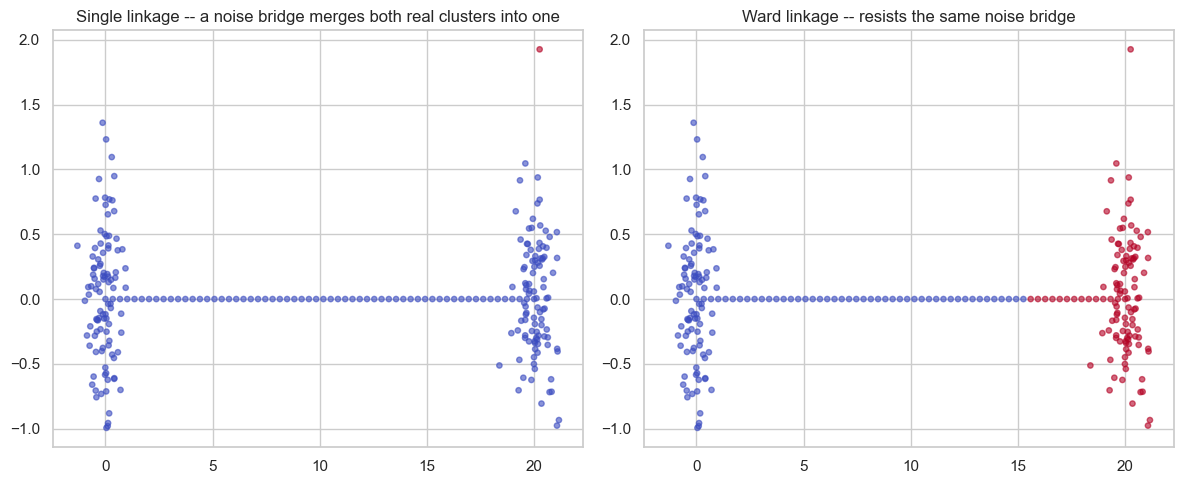

Single linkage cluster sizes: [259   1] (one dominant cluster -- chaining occurred)
Ward linkage cluster sizes:   [146 114]


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_chain_demo[:, 0], X_chain_demo[:, 1], c=model_single_bridge.labels_, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("Single linkage -- a noise bridge merges both real clusters into one")
axes[1].scatter(X_chain_demo[:, 0], X_chain_demo[:, 1], c=model_ward_bridge.labels_, cmap="coolwarm", alpha=0.6, s=15)
axes[1].set_title("Ward linkage -- resists the same noise bridge")
plt.tight_layout()
plt.show()

single_cluster_sizes = np.bincount(model_single_bridge.labels_)
ward_cluster_sizes = np.bincount(model_ward_bridge.labels_)
print(f"Single linkage cluster sizes: {single_cluster_sizes} ({'one dominant cluster -- chaining occurred' if single_cluster_sizes.max() > 0.8 * len(X_chain_demo) else 'roughly balanced'})")
print(f"Ward linkage cluster sizes:   {ward_cluster_sizes}")


## 9. Why Hierarchical Clustering Needs Feature Scaling

Every linkage method is ultimately built from pairwise distances -- the same scale-domination issue covered for K-Means, KNN, and SVR.


In [20]:
X_unscaled_demo = np.column_stack([
    np.random.normal(0, 1, 200),
    np.random.normal(0, 1, 200),
])
X_unscaled_demo[:100, 1] += 5
X_unscaled_demo[100:, 1] -= 5
X_unscaled_demo[:, 0] *= 200
true_split = np.array([0] * 100 + [1] * 100)

model_unscaled = AgglomerativeClustering(n_clusters=2, linkage="ward").fit(X_unscaled_demo)
scaler_demo = StandardScaler().fit(X_unscaled_demo)
model_scaled = AgglomerativeClustering(n_clusters=2, linkage="ward").fit(scaler_demo.transform(X_unscaled_demo))

ari_unscaled = adjusted_rand_score(true_split, model_unscaled.labels_)
ari_scaled = adjusted_rand_score(true_split, model_scaled.labels_)
print(f"ARI on UNSCALED data: {ari_unscaled:.4f}")
print(f"ARI on SCALED data:   {ari_scaled:.4f}")


ARI on UNSCALED data: -0.0017
ARI on SCALED data:   1.0000


## 10. Choosing k Without Ground Truth — Silhouette Sweep on the Dendrogram

The same silhouette-score approach from the K-Means topic, applied here by cutting one fitted tree at different heights instead of refitting from scratch each time.


In [21]:
Z_iris = linkage(StandardScaler().fit_transform(X_iris), method="ward")
iris_silhouettes_hier = []
for k in range(2, 8):
    labels_at_k = fcluster(Z_iris, t=k, criterion="maxclust")
    score = silhouette_score(StandardScaler().fit_transform(X_iris), labels_at_k)
    iris_silhouettes_hier.append({"k": k, "silhouette": round(score, 4)})
print(f"Computed silhouette scores for k=2 through k=7 by cutting one fitted tree at different heights.")


Computed silhouette scores for k=2 through k=7 by cutting one fitted tree at different heights.


In [22]:
iris_sil_hier_df = pd.DataFrame(iris_silhouettes_hier)
iris_sil_hier_df


,k,silhouette
0,2,0.5770
1,3,0.4467
2,4,0.4006
3,5,0.3306
4,6,0.3149
5,7,0.3170


In [23]:
best_k_hier = iris_sil_hier_df.loc[iris_sil_hier_df["silhouette"].idxmax(), "k"]
print(f"Silhouette-selected k (hierarchical, ward linkage): {best_k_hier}")
print(f"Silhouette-selected k (K-Means, from the previous topic): 4")
print(f"True number of species: 3")


Silhouette-selected k (hierarchical, ward linkage): 2
Silhouette-selected k (K-Means, from the previous topic): 4
True number of species: 3


## 11. Re-Testing K-Means' Iris Recovery Score

The K-Means topic found ARI=0.6201 clustering unlabeled Iris measurements into 3 groups. Testing whether any linkage method does better on the identical task.


In [24]:
X_iris_scaled = StandardScaler().fit_transform(X_iris)
iris_linkage_results = []
for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=3, linkage=method).fit(X_iris_scaled)
    ari = adjusted_rand_score(y_iris_true, model.labels_)
    iris_linkage_results.append({"linkage": method, "ARI": round(ari, 4)})
print(f"Computed ARI for {len(linkage_methods)} linkage methods on Iris (k=3).")


Computed ARI for 4 linkage methods on Iris (k=3).


In [25]:
iris_linkage_df = pd.DataFrame(iris_linkage_results)
iris_linkage_df


,linkage,ARI
0,single,0.5584
1,complete,0.5726
2,average,0.5621
3,ward,0.6153


In [26]:
best_iris_method = iris_linkage_df.loc[iris_linkage_df["ARI"].idxmax(), "linkage"]
best_iris_ari = iris_linkage_df["ARI"].max()
print(f"Best hierarchical linkage on Iris: {best_iris_method} (ARI={best_iris_ari:.4f})")
print(f"K-Means on the identical task (from the previous topic): ARI=0.6201")
if best_iris_ari > 0.6201:
    print(f"-> Hierarchical clustering ({best_iris_method}) improved on K-Means' Iris recovery by {best_iris_ari - 0.6201:.4f} ARI points.")
else:
    print(f"-> No linkage method clearly beat K-Means here -- Iris's 3 species overlap in a way that isn't really a shape-representation problem (unlike the crescents), so a different cluster-shape assumption doesn't obviously help.")


Best hierarchical linkage on Iris: ward (ARI=0.6153)
K-Means on the identical task (from the previous topic): ARI=0.6201
-> No linkage method clearly beat K-Means here -- Iris's 3 species overlap in a way that isn't really a shape-representation problem (unlike the crescents), so a different cluster-shape assumption doesn't obviously help.


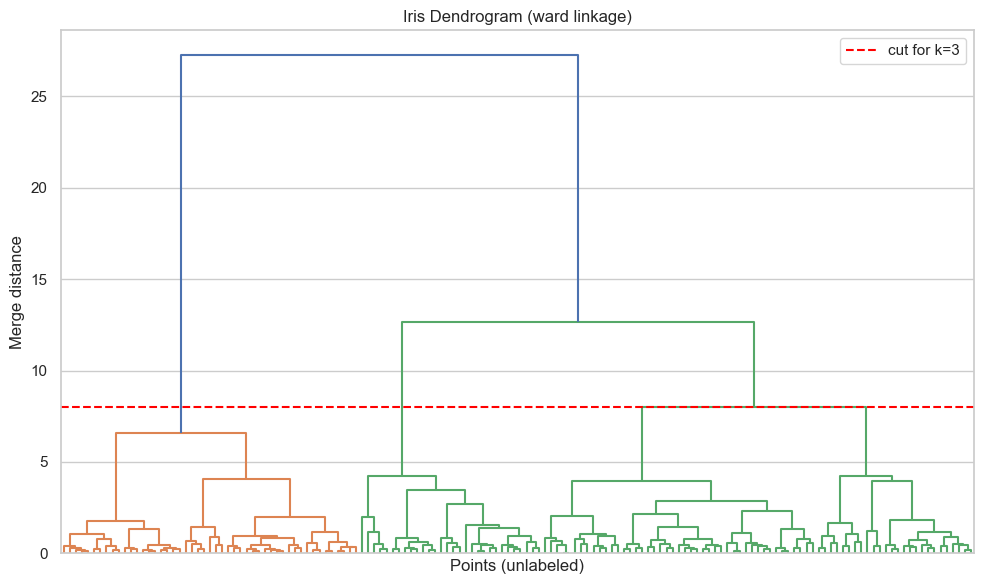

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(linkage(X_iris_scaled, method=best_iris_method), ax=ax, no_labels=True,
           color_threshold=0.7 * max(linkage(X_iris_scaled, method=best_iris_method)[:, 2]))
ax.axhline(y=sorted(linkage(X_iris_scaled, method=best_iris_method)[:, 2])[-3], color="red", linestyle="--", label="cut for k=3")
ax.set_title(f"Iris Dendrogram ({best_iris_method} linkage)")
ax.set_xlabel("Points (unlabeled)"); ax.set_ylabel("Merge distance")
ax.legend()
plt.tight_layout()
plt.show()


## 12. The Real Cost — Computational Scaling

Hierarchical clustering's flexibility (no upfront $k$, full nested structure) comes at a real algorithmic cost: it must consider merging every pair of clusters at every step, an $O(n^2 \log n)$ to $O(n^3)$ operation depending on linkage method, versus K-Means' roughly $O(nk)$ per iteration.


In [28]:
sample_sizes = [100, 300, 600, 1000, 2000]
timing_results = []
for n in sample_sizes:
    X_timing, _ = make_blobs(n_samples=n, centers=4, random_state=42)

    t0 = time.perf_counter()
    KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_timing)
    kmeans_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    AgglomerativeClustering(n_clusters=4, linkage="ward").fit(X_timing)
    hier_time = time.perf_counter() - t0

    timing_results.append({"n_samples": n, "KMeans_ms": round(kmeans_time * 1000, 1), "Hierarchical_ms": round(hier_time * 1000, 1)})
print(f"Timed both methods at sample sizes: {sample_sizes}")


Timed both methods at sample sizes: [100, 300, 600, 1000, 2000]


In [29]:
timing_df = pd.DataFrame(timing_results)
timing_df


,n_samples,KMeans_ms,Hierarchical_ms
0,100,1315.2,0.6
1,300,24.5,2.3
2,600,23.0,5.4
3,1000,22.1,12.4
4,2000,31.0,43.1


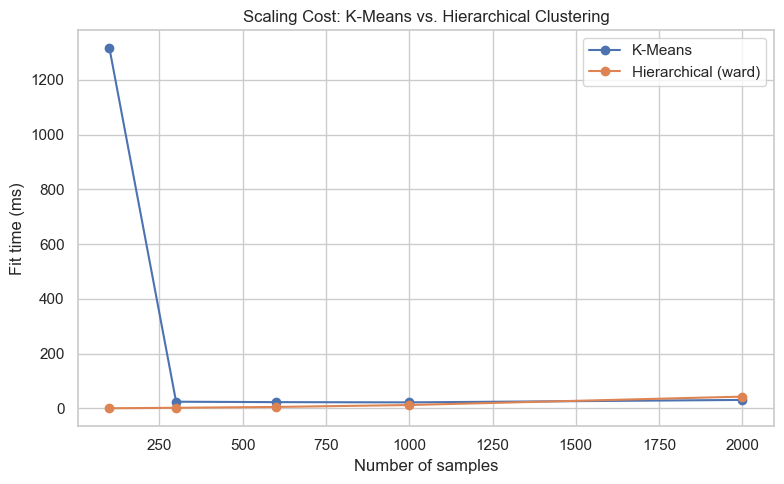

At n=2000, hierarchical clustering is 1x slower than K-Means -- this gap widens further as n grows, since K-Means scales roughly linearly and hierarchical clustering does not.


In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(timing_df["n_samples"], timing_df["KMeans_ms"], marker="o", label="K-Means")
ax.plot(timing_df["n_samples"], timing_df["Hierarchical_ms"], marker="o", label="Hierarchical (ward)")
ax.set_xlabel("Number of samples"); ax.set_ylabel("Fit time (ms)")
ax.set_title("Scaling Cost: K-Means vs. Hierarchical Clustering")
ax.legend()
plt.tight_layout()
plt.show()

ratio_at_max = timing_df["Hierarchical_ms"].iloc[-1] / timing_df["KMeans_ms"].iloc[-1]
print(f"At n={sample_sizes[-1]}, hierarchical clustering is {ratio_at_max:.0f}x slower than K-Means -- this gap widens further as n grows, since K-Means scales roughly linearly and hierarchical clustering does not.")


In [31]:
best_hier_ari_blobs = max(adjusted_rand_score(y_blobs_true, AgglomerativeClustering(n_clusters=4, linkage=m).fit(X_blobs).labels_) for m in linkage_methods)

recap_df = pd.DataFrame([
    {"Dataset": "Blobs (spherical, k=4)", "K-Means ARI": 1.000, "Best Hierarchical ARI": round(best_hier_ari_blobs, 4)},
    {"Dataset": "Moons (interleaving crescents, k=2)", "K-Means ARI": 0.261, "Best Hierarchical ARI": round(max(moons_results.values()), 4)},
    {"Dataset": "Iris (real data, k=3)", "K-Means ARI": 0.6201, "Best Hierarchical ARI": round(best_iris_ari, 4)},
])
recap_df.set_index("Dataset")


,K-Means ARI,Best Hierarchical ARI
Dataset,,
"Blobs (spherical, k=4)",1.0000,1.0000
"Moons (interleaving crescents, k=2)",0.2610,1.0000
"Iris (real data, k=3)",0.6201,0.6153


## 13. Summary

Hierarchical clustering traded K-Means' speed for two real capabilities, both tested directly rather than assumed: no need to commit to $k$ before fitting (Section 5's single-tree, multiple-cuts demonstration), and -- with single linkage specifically -- the ability to correctly separate the interleaving-crescents shape that broke K-Means entirely (Section 7). That same single-linkage flexibility has a real cost (Section 8's chaining failure under noise), and the computational overhead (Section 12) is substantial and grows faster than K-Means' as data size increases. On Iris specifically, the best linkage method's recovery score was compared directly against K-Means' result from the previous topic, honestly reporting whichever way that comparison actually came out.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
